# Embeddings Cache → Outlier Scores Pipeline

This notebook implements a **step-by-step** workflow that starts from long-format parquet extractions and produces per-sample anomaly/outlier scores using Presto embeddings.

**Full pipeline:**
```
Long-format parquets (.parquet or .geoparquet)
  → Wide time-series parquets (one per input file, process_parquet)
  → Merged wide parquet (single Arrow-streamed file)
  → DuckDB embeddings cache (Presto embeddings, keyed by sample_id + model_hash)
  → Outlier scores — LANDCOVER10 and CROPTYPE24 (run_pipeline from worldcereal.train.anomaly)
  → Merged scores DataFrame (one row per sample_id)
  → Scores appended back to input parquets (in-place for geoparquet, or to OUTPUT_LONG_DIR)
  → Scores appended back to merged wide parquet (Arrow-streamed, memory-safe)
```

**Two input layouts are supported — controlled by `INPUT_FORMAT` in section 1:**

| `INPUT_FORMAT` | Layout | Write-back |
|---|---|---|
| `"geoparquet"` | Flat folder of per-dataset `.geoparquet` files (VM) | **In-place**, geo metadata preserved |
| `"parquet"` | Nested hive-partitioned `.parquet` files (HPC) | Separate `OUTPUT_LONG_DIR` |

> **Note:** DuckDB may throw a lock error if the same `.duckdb` file is open for writing in another process or kernel.  Use a different DB path or close other connections before running the embeddings cells.


## Notebook structure

| # | Section | Description |
|---|---------|-------------|
| 1 | **Parameters** | All user-configurable paths, knobs, and **`PIPELINE_MODE`** (`"rerun"` or `"update"`) |
| 2 | **Discover inputs** | List long-format parquet files; count unique `(ref_id, sample_id)` pairs |
| 3 | **Long → Wide conversion** | Run `process_parquet` on each long file; write per-file wide parquets |
| 4 | **Merge wide parquets** | Stream-merge all wide parquets into a single file |
| 5 | **Populate embeddings cache** | Compute Presto embeddings and write to DuckDB (skips already-cached samples) |
| 6 | **Load class mappings** | Fetch LANDCOVER / CROPTYPE label legend from SharePoint |
| 7 | **Scoring — rerun mode** | Full scoring: run LC10 and CTY24 pipelines over the entire DuckDB cache |
| 7u | **Scoring — update mode** | Incremental: per-domain unscored detection → H3 impact zone → load only affected embeddings → score |
| 8 | **Merge LC10 + CTY24 scores** | Outer-join both score tables on `(ref_id, sample_id)` |
| 9 | **Write scores back — long parquets** | Broadcast anomaly columns to every row in the long-format files |
| 10 | **Write scores back — merged wide parquet** | Arrow-streaming join/update of scores into the merged wide parquet |
| — | **Optional: run pipeline as a script** | Single-command equivalent (for SLURM / screen) |
| 11 | **Explore embeddings cache** | Quick stats, random sample, PCA scatter plot |
| 12 | **DB comparison utilities** | Diagnostic cells for comparing row counts across DuckDB versions |

> **Which mode to use?**
> - **`rerun`**: Initial run, or when you want to re-score everything from scratch (HPC with plenty of RAM)
> - **`update`**: After adding new labelled datasets to an existing scored collection (VM-friendly, memory-efficient)


## 1) Parameters

Edit the variables below before running any other cells.  Everything else in the notebook reads from these names.

In [1]:

from __future__ import annotations

import gc
import os
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
import torch
from loguru import logger
from prometheo.models import Presto
from tqdm.auto import tqdm

from worldcereal.train.anomaly import run_pipeline
from worldcereal.train.anomaly_utils import (
    ANOMALY_COLUMNS as _ALL_ANOMALY_COLUMNS,
    LC10_ANOMALY_COLUMNS,
    CTY24_ANOMALY_COLUMNS,
    find_unscored_samples,
    compute_impact_zone,
    load_affected_embeddings_from_cache,
    merge_scores_to_long_parquets,
)
from worldcereal.train.embeddings_cache import compute_embeddings, get_model_hash
from worldcereal.utils.timeseries import process_parquet

# ============================================================
# IDENTITY
# ============================================================
# All output paths include `suffix` in their stem/dir name so you can run
# multiple variants side-by-side without clobbering existing results.
suffix = ""

# ============================================================
# PIPELINE MODE
# ============================================================
# 'rerun'  — full scoring of ALL samples from the DuckDB embeddings cache
#             (used for initial runs or when you want to re-score everything)
# 'update' — incremental: detect unscored samples, compute H3 impact zone,
#             load only impact-zone embeddings, re-score only affected slices
#             (used after adding new labelled datasets to an existing scored collection)
PIPELINE_MODE = "update"   # ← "rerun" or "update"

# ============================================================
# INPUT FORMAT
# ============================================================
# 'parquet'    — nested hive-partitioned .parquet files (HPC layout)
# 'geoparquet' — flat folder of per-dataset .geoparquet files (VM layout)
#
# This controls the PARQUET_GLOB and write-back behaviour.
# In 'geoparquet' mode scores are written back IN-PLACE to the same files
# (OUTPUT_LONG_DIR == INPUT_LONG_DIR) and the GeoParquet geo metadata is
# preserved so the files remain valid for GIS tools.
INPUT_FORMAT = "geoparquet"   # ← set to "parquet" for HPC / nested layout

# ============================================================
# PATHS  —  VM (edit this block for HPC by switching INPUT_FORMAT above)
# ============================================================

# --------------- VM paths ---------------
_VM_DATA = Path("/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL")

# (A) Long-format input: flat folder of .geoparquet files
INPUT_LONG_DIR = _VM_DATA / "MERGED_PARQUETS_PHASEII_WITH_ANOMALY"

# (B) Wide-format intermediate outputs
WIDE_DIR         = _VM_DATA / "CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets"
WIDE_SUFFIX      = "_ppq"
OVERWRITE_WIDE   = False
OVERWRITE_MERGED = False

MERGED_WIDE_PATH = (
    _VM_DATA / f"CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month{suffix}.parquet"
)

# (C) DuckDB embeddings cache
EMBEDDINGS_DB_PATH = (
    _VM_DATA / f"EMBEDDINGS_CACHE/embeddings_cache_LANDCOVER10_updated{suffix}.duckdb"
)

# (D) Presto model checkpoint
PRESTO_URL = (
    "https://artifactory.vgt.vito.be/artifactory/auxdata-public/worldcereal/models/"
    "PhaseII/presto-ss-wc_longparquet_random-window-cut_no-time-token_epoch96.pt"
)

# ----------------------------------------------------------
# (E) Outlier score output directories
# ----------------------------------------------------------
_OUTLIERS_DIR = _VM_DATA / "EMBEDDINGS_CACHE"

OUT_LC10_DIR  = _OUTLIERS_DIR / f"h3levels23_10kmax_mad4_jsonLC10{suffix}"
OUT_CTY24_DIR = _OUTLIERS_DIR / f"h3levels234_5kmax_mad4_jsonCTY24{suffix}"

LC10_SAMPLES_PATH = str(OUT_LC10_DIR / f"h3levels23_10kmax_mad4_jsonLC10{suffix}.parquet")
LC10_SUMMARY_PATH = str(OUT_LC10_DIR / f"h3levels23_10kmax_mad4_jsonLC10_summary{suffix}.parquet")

CTY24_SAMPLES_PATH = str(OUT_CTY24_DIR / f"h3levels234_5kmax_mad4_jsonCTY24{suffix}.parquet")
CTY24_SUMMARY_PATH = str(OUT_CTY24_DIR / f"h3levels234_5kmax_mad4_jsonCTY24_summary{suffix}.parquet")

# Anomaly columns to broadcast to the long-format parquets
ANOMALY_COLS = [
    "CTY24_confidence_nonoutlier",  # 0-1 confidence the sample is not a CTY24 outlier
    "CTY24_anomaly_flag",           # normal / flagged / suspect / candidate (CTY24)
    "outlier_CTY24_cls",            # CTY24 class name used for this sample
    "LC10_confidence_nonoutlier",   # 0-1 confidence the sample is not a LC10 outlier
    "LC10_anomaly_flag",            # normal / flagged / suspect / candidate (LC10)
    "outlier_LC10_cls",             # LC10 class name used for this sample
]

# Merged scores (outer-join of LC10 + CTY24, one row per sample_id)
MERGED_SCORES_PATH = _OUTLIERS_DIR / f"merged_LC10_CTY24_flagged_gdf{suffix}.parquet"

# ----------------------------------------------------------
# (F) Score merge-back: outputs
# ----------------------------------------------------------
# In 'geoparquet' mode: scores are written back IN-PLACE (same dir as input).
# In 'parquet' mode: set OUTPUT_LONG_DIR to a separate output directory.
if INPUT_FORMAT == "geoparquet":
    OUTPUT_LONG_DIR = INPUT_LONG_DIR          # in-place update
    PARQUET_GLOB    = "*.geoparquet"          # flat folder, no recursion needed
else:
    # HPC / nested layout — adjust user_home and paths as needed
    _HPC_HOME = Path("/home/vito/shahs")
    INPUT_LONG_DIR  = _HPC_HOME / "projects/worldcereal/data/worldcereal_all_extractions.parquet"
    OUTPUT_LONG_DIR = _HPC_HOME / f"projects/worldcereal/data/worldcereal_all_extractions_with_anomalies{suffix}.parquet"
    PARQUET_GLOB    = "**/*.parquet"

# Merged wide parquet with anomaly columns appended
OUTPUT_WIDE_WITH_SCORES_PATH = MERGED_WIDE_PATH.parent / (MERGED_WIDE_PATH.stem + "_with_anomalies.parquet")

# ============================================================
# PIPELINE KNOBS
# ============================================================

# (A) long → wide conversion
FREQ = "month"               # 'month' or 'dekad'
REQUIRED_MIN_TIMESTEPS = None  # int | None — drop samples with fewer timesteps
USE_VALID_TIME = True
MIN_EDGE_BUFFER = 1
MAX_TIMESTEPS_TRIM = 18      # int | 'auto' | None
WIDE_ENGINE = "pyarrow"      # 'pyarrow' or 'fastparquet'
WIDE_COMPRESSION = "snappy"
MAX_LONG_FILES = None        # int | None — limit files for quick tests (e.g. 5)

# (B) merge wide parquets
MERGE_BATCH_ROWS    = 100_000
MERGE_ROW_GROUP_SIZE = 100_000
MERGE_COMPRESSION   = "zstd"

# (C) embeddings cache population
BATCH_SIZE        = 16_384
NUM_WORKERS       = 8
PARQUET_BATCH_ROWS = 300_000  # rows read per Arrow batch; iterate ALL batches per file
FORCE_RECOMPUTE   = False     # True → delete + recompute embeddings for all samples
PREMATCH          = True      # True → skip parquet batches already fully cached

# (D) Update mode knobs
NEIGHBOUR_RINGS = 1  # H3 neighbour rings added around the new-data impact zone

# ============================================================
# SANITY CHECKS
# ============================================================
assert INPUT_LONG_DIR.exists(), f"Input path not found: {INPUT_LONG_DIR}"
OUT_LC10_DIR.mkdir(parents=True, exist_ok=True)
OUT_CTY24_DIR.mkdir(parents=True, exist_ok=True)

print(f"Pipeline mode  : {PIPELINE_MODE}")
print(f"Input format   : {INPUT_FORMAT}")
print(f"Input long dir : {INPUT_LONG_DIR}")
print(f"Parquet glob   : {PARQUET_GLOB}")
print(f"Wide dir       : {WIDE_DIR}")
print(f"Merged wide    : {MERGED_WIDE_PATH}")
print(f"Embeddings DB  : {EMBEDDINGS_DB_PATH}")
print(f"Output long dir: {OUTPUT_LONG_DIR}  {'(in-place)' if OUTPUT_LONG_DIR == INPUT_LONG_DIR else ''}")
if PIPELINE_MODE == "update":
    print(f"Neighbour rings: {NEIGHBOUR_RINGS}")


Pipeline mode  : update
Input format   : geoparquet
Input long dir : /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/MERGED_PARQUETS_PHASEII_WITH_ANOMALY
Parquet glob   : *.geoparquet
Wide dir       : /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets
Merged wide    : /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month.parquet
Embeddings DB  : /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/EMBEDDINGS_CACHE/embeddings_cache_LANDCOVER10_updated.duckdb
Output long dir: /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/MERGED_PARQUETS_PHASEII_WITH_ANOMALY  (in-place)
Neighbour rings: 1


## 2) Discover long-format parquet inputs

List all long-format parquet files matched by `PARQUET_GLOB` and count the unique `(ref_id, sample_id)` pairs across all files.  This is a read-only step — it does not produce any output files.

In [2]:
raw_files = sorted(INPUT_LONG_DIR.glob(PARQUET_GLOB))
if MAX_LONG_FILES:
    raw_files = raw_files[:MAX_LONG_FILES]
print(f"Found {len(raw_files)} long-format parquet files (glob: '{PARQUET_GLOB}').")

all_ref_ids_samples: set = set()
for f in tqdm(raw_files, desc="Scanning long parquets", unit="file"):
    df = pd.read_parquet(f, columns=["ref_id", "sample_id"])
    ref_id_sample_pairs = set(zip(df["ref_id"], df["sample_id"]))
    all_ref_ids_samples.update(ref_id_sample_pairs)

print(f"Found {len(all_ref_ids_samples):,} unique (ref_id, sample_id) pairs.")


Found 340 long-format parquet files (glob: '*.geoparquet').


Scanning long parquets:   0%|          | 0/340 [00:00<?, ?file/s]

Found 7,081,911 unique (ref_id, sample_id) pairs.


## 3) Convert long → wide via `process_parquet`

For every long-format parquet file, call `worldcereal.utils.timeseries.process_parquet` to pivot the stacked time-series rows into a wide format (one row per sample, one column per band×timestep).  Output files land in `WIDE_DIR` with the `WIDE_SUFFIX` suffix.

Already-converted files are skipped unless `OVERWRITE_WIDE = True`.

In [3]:
def wide_out_path(wide_dir: Path, raw_path: Path, suffix: str = "_ppq") -> Path:
    # Strip ALL extensions so both .parquet and .geoparquet are handled uniformly
    # e.g. 2019_BGR_Eurocrops_POLY_110.geoparquet → 2019_BGR_Eurocrops_POLY_110_ppq.parquet
    stem = raw_path.name
    for ext in (".geoparquet", ".parquet"):
        if stem.endswith(ext):
            stem = stem[: -len(ext)]
            break
    return wide_dir / f"{stem}{suffix}.parquet"

WIDE_DIR.mkdir(parents=True, exist_ok=True)
already_processed = 0
wide_files: list[Path] = []
empty_long: list[Path] = []
errored_long: list[Path] = []

for pf in tqdm(raw_files, desc="process_parquet", unit="file"):
    out_path = wide_out_path(WIDE_DIR, pf, suffix=WIDE_SUFFIX)
    if out_path.exists() and not OVERWRITE_WIDE:
        already_processed += 1
        wide_files.append(out_path)
        continue
    try:
        df_long = pd.read_parquet(pf)
        # Some upstream outputs store sample_id in the index instead of a column
        if "sample_id" not in df_long.columns and "sample_id" in df_long.index.names:
            print("Resetting index to get sample_id column")
            df_long.reset_index(drop=True, inplace=True)
        df_wide = process_parquet(
            df_long,
            freq=FREQ,
            required_min_timesteps=REQUIRED_MIN_TIMESTEPS,
            use_valid_time=USE_VALID_TIME,
            min_edge_buffer=MIN_EDGE_BUFFER,
            max_timesteps_trim=MAX_TIMESTEPS_TRIM,
        )
    except Exception as e:
        print(f"ERROR processing {pf}: {type(e).__name__}: {e}")
        errored_long.append(pf)
        raise e

    if df_wide.empty:
        empty_long.append(pf)
        continue

    df_wide = df_wide.reset_index()
    df_wide.sort_values("sample_id", inplace=True)
    df_wide.to_parquet(
        out_path,
        engine=WIDE_ENGINE,
        compression=WIDE_COMPRESSION,
        index=False,
    )
    wide_files.append(out_path)
    del df_long, df_wide
    gc.collect()

print(f"Already processed (skipped) : {already_processed}")
print(f"Produced / available        : {len(wide_files)}")
if empty_long:
    print(f"Empty after process_parquet : {len(empty_long)}")
if errored_long:
    print(f"Errors during conversion    : {len(errored_long)}")
display([str(p) for p in wide_files[:10]])


process_parquet:   0%|          | 0/340 [00:00<?, ?file/s]

Already processed (skipped) : 340
Produced / available        : 340


['/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets/2017_AF_One-Acre-Fund-MEL_POINT_110_ppq.parquet',
 '/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets/2017_ARG_LISTA-field-data_POLY_110_ppq.parquet',
 '/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets/2017_AS_CAWA-project_POLY_111_ppq.parquet',
 '/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets/2017_AUT_LPIS_POLY_110_ppq.parquet',
 '/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets/2017_BEL_LPIS-Flanders_POLY_110_ppq.parquet',
 '/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquets/2017_BFA_JECAM-CIRAD_POLY_111_ppq.parquet',
 '/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_me

In [ ]:
# -----------------------------------------------------------------------
# OPTIONAL: Backfill missing wide files from an earlier run
#
# If a previous processing run (e.g. with different SCL settings) already
# produced wide parquets for most files and only a few are missing in the
# new directory, this cell fills the gap by borrowing the earlier files
# instead of reprocessing from scratch.
#
# Uncomment and adjust the directory paths as needed.
# -----------------------------------------------------------------------

# earlier_dir = Path("/projects/worldcereal/data/cached_wide_merged/cached_wide_parquets")
# new_dir     = Path("/projects/worldcereal/data/cached_wide_merged/cached_wide_parquets_raw_scl")

# wide_files_earlier_all = list(earlier_dir.glob("*.parquet"))
# wide_files_new_all     = list(new_dir.glob("*.parquet"))

# # Compare by filename stem only (ignore directory)
# wide_files_earlier_stems = {p.stem: p for p in wide_files_earlier_all}
# wide_files_new_stems     = {p.stem: p for p in wide_files_new_all}

# missing_stems = set(wide_files_earlier_stems.keys()) - set(wide_files_new_stems.keys())
# print(f"Missing wide files from earlier runs : {len(missing_stems)}")
# print(f"New wide files (current run)         : {len(wide_files_new_all)}")

# # Resolve paths for the missing files (taken from the earlier folder)
# missing_wide_files = [wide_files_earlier_stems[stem] for stem in sorted(missing_stems)]

# # Override wide_files: new run files + backfilled missing
# wide_files = sorted(wide_files_new_all) + missing_wide_files
# print(f"Total wide files (new + backfilled)  : {len(wide_files)}")

Missing wide files from earlier runs: 30
New raw_scl wide files: 290
Total wide files to process (new + backfilled missing): 320


## 4) Merge wide parquets into one (Arrow streaming)

Streams all per-file wide parquets into a single merged parquet file using PyArrow.  The implementation handles minor schema differences across files (different columns or types) by computing a unified target schema and casting/null-filling as needed.

This step is **memory-safe**: files are read in row-group batches and written incrementally; the full dataset is never loaded at once.

Output goes to `MERGED_WIDE_PATH`.  Skipped if the file already exists and `OVERWRITE_MERGED = False`.

In [4]:
def _is_numeric(t: pa.DataType) -> bool:
    return pa.types.is_integer(t) or pa.types.is_floating(t) or pa.types.is_decimal(t)


def _build_target_schema(files: list[Path]) -> pa.Schema:
    """Build a unified Arrow schema from the union of all file schemas.

    When the same column has multiple types across files, the resolution
    rules are:
    - Any numeric type  → float32
    - Any timestamp     → timestamp("us")
    - Any bool present  → bool_
    - Anything else     → string
    """
    type_map: dict[str, set[pa.DataType]] = {}
    for f in files:
        sch = pq.ParquetFile(str(f)).schema_arrow
        for field in sch:
            type_map.setdefault(field.name, set()).add(field.type)

    fields: list[pa.Field] = []
    for name, typeset in sorted(type_map.items()):
        if len(typeset) == 1:
            fields.append(pa.field(name, next(iter(typeset))))
            continue
        if any(_is_numeric(t) for t in typeset):
            fields.append(pa.field(name, pa.float32()))
        elif any(pa.types.is_timestamp(t) for t in typeset):
            fields.append(pa.field(name, pa.timestamp("us")))
        elif any(pa.types.is_boolean(t) for t in typeset):
            fields.append(pa.field(name, pa.bool_()))
        else:
            fields.append(pa.field(name, pa.string()))
    return pa.schema(fields)


def _align_table_to_schema(tbl: pa.Table, schema: pa.Schema) -> pa.Table:
    """Cast / null-fill a table so it matches *schema* exactly."""
    arrays = []
    for field in schema:
        name = field.name
        if name in tbl.column_names:
            col = tbl[name]
            if not col.type.equals(field.type):
                col = pc.cast(col, field.type, safe=False)
            arrays.append(col)
        else:
            arrays.append(pa.nulls(tbl.num_rows, type=field.type))
    return pa.Table.from_arrays(arrays, schema=schema)


def merge_parquets_stream_to_one(
    files: list[Path],
    out_path: Path,
    *,
    batch_rows: int = 100_000,
    row_group_size: int = 100_000,
    compression: str = "zstd",
    overwrite: bool = False,
) -> Path:
    """Stream-merge a list of parquet files into a single output file."""
    if not files:
        raise ValueError("No input parquet files provided for merge.")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists() and not overwrite:
        print(f"Skipping merge — output already exists: {out_path}")
        return out_path

    target_schema = _build_target_schema(files)
    print(f"Merge target schema: {len(target_schema)} fields")

    writer = pq.ParquetWriter(
        str(out_path),
        target_schema,
        compression=compression,
        use_dictionary=True,
        write_statistics=True,
    )
    total_rows = 0
    try:
        for fi, f in enumerate(files, start=1):
            pf = pq.ParquetFile(str(f))
            print(f"[{fi}/{len(files)}] {f.name}  ({pf.metadata.num_rows:,} rows)")
            for batch in pf.iter_batches(batch_size=batch_rows):
                tbl = pa.Table.from_batches([batch])
                tbl = _align_table_to_schema(tbl, target_schema)
                writer.write_table(tbl, row_group_size=row_group_size)
                total_rows += tbl.num_rows
                del batch, tbl
                gc.collect()
        print(f"Merge complete — {total_rows:,} rows written → {out_path}")
    finally:
        writer.close()
    return out_path


merged_wide_path = merge_parquets_stream_to_one(
    wide_files,
    MERGED_WIDE_PATH,
    batch_rows=MERGE_BATCH_ROWS,
    row_group_size=MERGE_ROW_GROUP_SIZE,
    compression=MERGE_COMPRESSION,
    overwrite=OVERWRITE_MERGED,
)
print("Merged wide parquet:", merged_wide_path)

Skipping merge — output already exists: /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month.parquet
Merged wide parquet: /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month.parquet


## 5) Populate / update the DuckDB embeddings cache

Reads the **individual wide parquet files** (not the merged parquet) in Arrow batches and calls `compute_embeddings()` on each batch.  The function skips sample IDs that are already present in the cache for this model hash, so re-running is safe and incremental.

Key points:
- All batches within a file are iterated — previously a `next()` on the iterator silently dropped everything beyond the first `PARQUET_BATCH_ROWS` rows.
- `FORCE_RECOMPUTE = True` deletes existing cache entries for all samples before inserting fresh ones.
- Loguru is set to `WARNING` level to suppress the per-batch debug output.

In [ ]:
# Suppress debug/info noise from the embeddings cache internals
logger.remove()
logger.add(sys.stderr, level="WARNING")

if not WIDE_DIR.exists():
    raise FileNotFoundError(f"Wide directory not found: {WIDE_DIR}")

wide_files_for_cache = sorted(WIDE_DIR.glob(f"*{WIDE_SUFFIX}.parquet"))
if not wide_files_for_cache:
    raise RuntimeError(f"No wide parquet files found under: {WIDE_DIR}")
print(f"Found {len(wide_files_for_cache)} wide parquet files to embed.")

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {torch_device}")

model = Presto(pretrained_model_path=PRESTO_URL)
model.eval().to(torch_device)
model_hash = get_model_hash(model)
print(f"Model hash: {model_hash}")

for wide_file in tqdm(wide_files_for_cache, desc="Embedding files", unit="file"):
    pf = pq.ParquetFile(str(wide_file))
    total_rows = pf.metadata.num_rows

    # Iterate ALL Arrow batches in the file.
    # (Using next() on the iterator would silently drop everything beyond
    # the first PARQUET_BATCH_ROWS rows.)
    rows_processed = 0
    for batch in pf.iter_batches(batch_size=PARQUET_BATCH_ROWS):
        tbl = pa.Table.from_batches([batch])
        df = tbl.to_pandas()
        rows_processed += len(df)
        compute_embeddings(
            df,
            model=model,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            embeddings_db_path=str(EMBEDDINGS_DB_PATH),
            force_recompute=FORCE_RECOMPUTE,
            show_progress=True,
        )
        del batch, tbl, df
        gc.collect()

print("Embeddings cache population complete.")

Found 340 wide parquet files to embed.
Using device: cpu
Model hash: 9236078179d9268019190f3aa8ad6920927f766845ae0db8483eeea9f1500fc4
Embeddings cache population complete.
Model hash: 9236078179d9268019190f3aa8ad6920927f766845ae0db8483eeea9f1500fc4
Embeddings cache population complete.


In [ ]:
# -----------------------------------------------------------------------
# ALTERNATIVE: Run embeddings from the merged wide parquet (if RAM permits)
#
# Reading everything at once is faster (single pass) but requires enough
# memory to hold the full merged wide parquet.  For very large datasets
# prefer the file-by-file approach above.
# -----------------------------------------------------------------------

# df_merged = pd.read_parquet(str(MERGED_WIDE_PATH))
# compute_embeddings(
#     df_merged,
#     model=model,
#     batch_size=BATCH_SIZE,
#     num_workers=NUM_WORKERS,
#     embeddings_db_path=str(EMBEDDINGS_DB_PATH),
#     force_recompute=FORCE_RECOMPUTE,
#     show_progress=True,
# )

## 6) Load class mappings from SharePoint

The outlier pipeline needs a mapping from raw `ewoc_code` integers to human-readable class names (e.g. `LANDCOVER10`, `CROPTYPE24`).  The mapping is maintained in an Excel file on SharePoint and fetched via the Microsoft Graph API.

Credentials are loaded from a `.sharepointenv` file (not committed to git).  The variables `WORLDCEREAL_SP_SITE_URL` and `WORLDCEREAL_SP_FILE_URL` must be set there.

The resulting `CLASS_MAPPINGS` dict is keyed by mapping name (e.g. `"LANDCOVER10"`, `"CROPTYPE24"`) and will be passed to `run_pipeline` below.

In [6]:
import os
import pandas as pd
from dotenv import load_dotenv

from worldcereal.utils.sharepoint import (
    get_excel_from_sharepoint,
    build_class_mappings,
)

# Load SharePoint credentials from .sharepointenv (not committed to git)
# Try VM path first, then HPC path
_env_candidates = [
    Path("/home/wcextractions/.sharepointenv"),        # VM
    Path("/home/vito/shahs/TestFolder/.sharepointenv"),  # HPC
]
_env_path = next((p for p in _env_candidates if p.exists()), None)
assert _env_path is not None, (
    f".sharepointenv not found at any of: {[str(p) for p in _env_candidates]}"
)
print(f"Using .sharepointenv: {_env_path}")
load_dotenv(_env_path, override=True)

SITE_URL = os.environ["WORLDCEREAL_SP_SITE_URL"]
FILE_URL  = os.environ["WORLDCEREAL_SP_FILE_URL"]

# Fetch legend Excel from SharePoint (built-in retry logic)
legend = get_excel_from_sharepoint(
    site_url=SITE_URL,
    file_server_relative_url=FILE_URL,
    retries=10,
    sheet_name=0,
)
print("Successfully fetched legend from SharePoint")

# Normalize ewoc_code: strip dashes, coerce to integer
legend["ewoc_code"] = (
    legend["ewoc_code"]
    .astype("string")
    .str.replace("-", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
    .astype("Int64")
)

CLASS_MAPPINGS = build_class_mappings(legend)
print("CLASS_MAPPINGS keys:", list(CLASS_MAPPINGS.keys()))


Using .sharepointenv: /home/wcextractions/.sharepointenv
Successfully fetched legend from SharePoint
CLASS_MAPPINGS keys: ['LANDCOVER10', 'CROPTYPE24']
Successfully fetched legend from SharePoint
CLASS_MAPPINGS keys: ['LANDCOVER10', 'CROPTYPE24']


## 7) Scoring — RERUN mode

> **Skip this section if `PIPELINE_MODE = "update"`** — jump to section 7u below instead.

Scores every sample in the DuckDB embeddings cache against its spatial neighbours.  This loads the **full** cache and is intended for HPC with plenty of RAM.

### 7a) LANDCOVER10 (rerun)

Key parameters:
- `h3_level = [2, 3]` — adaptive: coarser level for sparse regions, finer for dense ones
- `max_slice_size = 10 000` — caps how large a slice can be before it's pushed to a finer H3 level
- `mad_k = 4.0` — number of MADs above the median to flag as an outlier
- `skip_classes = ["ignore"]` — samples mapped to the "ignore" class are excluded from scoring


In [ ]:
LC10_flagged_gdf, LC10_summary_df = run_pipeline(
    embeddings_db_path=str(EMBEDDINGS_DB_PATH),
    restrict_model_hash=None,
    label_domain="LANDCOVER10",
    map_to_finetune=False,
    class_mappings_name="LANDCOVER10",
    skip_classes=["ignore"],
    mapping_file=CLASS_MAPPINGS,
    h3_level=[2, 3],            # adaptive: coarse → fine
    group_cols=None,
    min_slice_size=200,
    max_slice_size=10_000,
    merge_small_slice=True,
    max_merge_iterations=16,
    threshold_mode="mad",
    percentile_q=0.96,
    mad_k=4.0,
    abs_threshold=None,
    fdr_alpha=0.05,
    min_flagged_per_slice=None,
    max_flagged_fraction=None,
    max_full_pairwise_n=0,      # disable full pairwise matrix (expensive)
    norm_percentiles=(2.0, 98.0),
    output_samples_path=LC10_SAMPLES_PATH,
    output_summary_path=LC10_SUMMARY_PATH,
    debug=False,
)
print(f"LC10 pipeline done — {len(LC10_flagged_gdf):,} samples scored.")

[anomaly] Connecting DuckDB and loading cached embeddings...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[anomaly] Loaded 6,936,439 rows from embeddings_cache
[anomaly] Mapping classes using mapping_file: {'LANDCOVER10': {'0': 'ignore', '1000000000': 'ignore', '1100000000': 'temporary_crops', '1101000000': 'temporary_crops', '1101000001': 'temporary_crops', '1101000002': 'temporary_crops', '1101010000': 'temporary_crops', '1101010001': 'temporary_crops', '1101010002': 'temporary_crops', '1101010003': 'temporary_crops', '1101010004': 'temporary_crops', '1101010005': 'temporary_crops', '1101010010': 'temporary_crops', '1101010011': 'temporary_crops', '1101010012': 'temporary_crops', '1101010020': 'temporary_crops', '1101010021': 'temporary_crops', '1101010022': 'temporary_crops', '1101010030': 'temporary_crops', '1101010031': 'temporary_crops', '1101010032': 'temporary_crops', '1101010040': 'temporary_crops', '1101010041': 'temporary_crops', '1101010042': 'temporary_crops', '1101010050': 'temporary_crops', '1101010051': 'temporary_crops', '1101010052': 'temporary_crops', '1101010060': 'temp

Scoring slices: 100%|██████████| 3604/3604 [35:24<00:00,  1.70slice/s, 2,173 pts | temporary_crops]        



[anomaly] Flagging anomalies (mode=mad)...


/home/vito/shahs/.conda/envs/radix_update/lib/python3.10/site-packages/worldcereal/train/anomaly_utils.py:1359: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_flag_group)


[anomaly] Computing robust confidence for flagged points...
[anomaly] Computing kNN label purity for flagged points...
[anomaly] Applying confidence fusion...
[anomaly] Applying confidence fusion...


/home/vito/shahs/.conda/envs/radix_update/lib/python3.10/site-packages/worldcereal/train/anomaly.py:880: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  flagged_df = pd.concat([flagged_df, df_skipped], axis=0, ignore_index=True)


[anomaly] Re-attached 554,702 skipped-class rows with NaN scores.
[anomaly] Writing flagged samples -> /home/vito/shahs/TestFolder/wc_outliers/h3levels23_10kmax_mad4_jsonLC10_new/h3levels23_10kmax_mad4_jsonLC10_new.parquet
[anomaly] Writing flagged samples -> /home/vito/shahs/TestFolder/wc_outliers/h3levels23_10kmax_mad4_jsonLC10_new/h3levels23_10kmax_mad4_jsonLC10_new.parquet
[anomaly] Writing summary -> /home/vito/shahs/TestFolder/wc_outliers/h3levels23_10kmax_mad4_jsonLC10_new/h3levels23_10kmax_mad4_jsonLC10_summary_new.parquet
[anomaly] Writing summary -> /home/vito/shahs/TestFolder/wc_outliers/h3levels23_10kmax_mad4_jsonLC10_new/h3levels23_10kmax_mad4_jsonLC10_summary_new.parquet


In [15]:
# Read back from disk (useful if resuming the notebook without re-running the pipeline)
import pandas as pd
from vito_crop_classification.inference.utils import read_parquet_chunked_to_df

LC10_flagged_gdf = read_parquet_chunked_to_df(
    LC10_SAMPLES_PATH,
    columns=["ref_id", "sample_id", "LANDCOVER10", "confidence_nonoutlier", "anomaly_flag"],
)

TRACE:root:2026/04/07 12:16:14 735054 |  TRACE   | [chunked-read]: Total 6936421 rows, reading in batches of 500000 rows.
TRACE:root:2026/04/07 12:16:37 177517 |  TRACE   | [chunked-read] Finished /home/vito/shahs/TestFolder/wc_outliers/h3levels23_10kmax_mad4_jsonLC10_new/h3levels23_10kmax_mad4_jsonLC10_new.parquet: 6936421 rows, 5 columns.
TRACE:root:2026/04/07 12:16:37 177517 |  TRACE   | [chunked-read] Finished /home/vito/shahs/TestFolder/wc_outliers/h3levels23_10kmax_mad4_jsonLC10_new/h3levels23_10kmax_mad4_jsonLC10_new.parquet: 6936421 rows, 5 columns.


In [16]:
# Keep only the anomaly columns relevant for downstream merging and rename for clarity
LC10_flagged_gdf = LC10_flagged_gdf[
    ["ref_id", "sample_id", "LANDCOVER10", "confidence_nonoutlier", "anomaly_flag"]
]
LC10_flagged_gdf = LC10_flagged_gdf.rename(columns={
    "confidence_nonoutlier": "LC10_confidence_nonoutlier",
    "anomaly_flag":          "LC10_anomaly_flag",
    "LANDCOVER10":           "outlier_LC10_cls",
})
print(f"LC10 scores: {len(LC10_flagged_gdf):,} rows")
LC10_flagged_gdf.head()

LC10 scores: 6,936,421 rows


,ref_id,sample_id,outlier_LC10_cls,LC10_confidence_nonoutlier,LC10_anomaly_flag
0,2019_GLO_EWOCO-v2_POINT_100,2019_GLO_EWOCO-v2_POINT_100_33,water,1.0,normal
1,2018_GLO_EWOCO-v2_POINT_100,2018_GLO_EWOCO-v2_POINT_100_76070,bare_sparsely_vegetated,1.0,normal
2,2018_GLO_EWOCO-v2_POINT_100,2018_GLO_EWOCO-v2_POINT_100_76071,bare_sparsely_vegetated,1.0,normal
3,2018_GLO_GLANCE_POINT_100,2018_GLO_GLANCE_POINT_100_04_01_00_2_1288532_2...,bare_sparsely_vegetated,1.0,normal
4,2018_GLO_GLANCE_POINT_100,2018_GLO_GLANCE_POINT_100_04_01_00_2_1500218_2...,bare_sparsely_vegetated,1.0,normal


### 7b) CROPTYPE24 (rerun)

Same approach as LC10 but using the finer `CROPTYPE24` label schema (24 crop-type classes).  Because crop-type classes are more numerous and individual classes are sparser, we use three H3 levels (`[2, 3, 4]`) with a smaller per-slice cap (`max_slice_size = 5 000`) to keep slices manageable.


In [11]:
CTY24_flagged_gdf, CTY24_summary_df = run_pipeline(
    embeddings_db_path=str(EMBEDDINGS_DB_PATH),
    restrict_model_hash=None,
    label_domain="CROPTYPE24",
    map_to_finetune=False,
    class_mappings_name="CROPTYPE24",
    skip_classes=["ignore"],
    mapping_file=CLASS_MAPPINGS,
    h3_level=[2, 3, 4],         # adaptive: coarse → fine (3 levels for sparse crop types)
    group_cols=None,
    min_slice_size=100,
    max_slice_size=5_000,
    merge_small_slice=True,
    max_merge_iterations=8,
    threshold_mode="mad",
    percentile_q=0.96,
    mad_k=4.0,
    abs_threshold=None,
    fdr_alpha=0.05,
    min_flagged_per_slice=None,
    max_flagged_fraction=None,
    max_full_pairwise_n=0,      # disable full pairwise matrix (expensive)
    norm_percentiles=(2.0, 98.0),
    output_samples_path=CTY24_SAMPLES_PATH,
    output_summary_path=CTY24_SUMMARY_PATH,
    debug=False,
)
print(f"CTY24 pipeline done — {len(CTY24_flagged_gdf):,} samples scored.")

NameError: name 'run_pipeline' is not defined

In [17]:
# Read back from disk (useful if resuming the notebook without re-running the pipeline)
import pandas as pd
from vito_crop_classification.inference.utils import read_parquet_chunked_to_df

CTY24_flagged_gdf = read_parquet_chunked_to_df(
    CTY24_SAMPLES_PATH,
    columns=["ref_id", "sample_id", "CROPTYPE24", "confidence_nonoutlier", "anomaly_flag"],
)

TRACE:root:2026/04/07 12:16:38 740703 |  TRACE   | [chunked-read]: Total 6936421 rows, reading in batches of 500000 rows.
TRACE:root:2026/04/07 12:17:06 001851 |  TRACE   | [chunked-read] Finished /home/vito/shahs/TestFolder/wc_outliers/h3levels234_5kmax_mad4_jsonCTY24_new/h3levels234_5kmax_mad4_jsonCTY24_new.parquet: 6936421 rows, 5 columns.
TRACE:root:2026/04/07 12:17:06 001851 |  TRACE   | [chunked-read] Finished /home/vito/shahs/TestFolder/wc_outliers/h3levels234_5kmax_mad4_jsonCTY24_new/h3levels234_5kmax_mad4_jsonCTY24_new.parquet: 6936421 rows, 5 columns.


In [ ]:
# Keep only the anomaly columns relevant for downstream merging and rename for clarity
CTY24_flagged_gdf = CTY24_flagged_gdf[
    ["ref_id", "sample_id", "CROPTYPE24", "confidence_nonoutlier", "anomaly_flag"]
]
CTY24_flagged_gdf = CTY24_flagged_gdf.rename(columns={
    "confidence_nonoutlier": "CTY24_confidence_nonoutlier",
    "anomaly_flag":          "CTY24_anomaly_flag",
    "CROPTYPE24":            "outlier_CTY24_cls",
})
print(f"CTY24 scores: {len(CTY24_flagged_gdf):,} rows")
CTY24_flagged_gdf.head()

# In rerun mode: all files are rewritten during write-back (no ref_id filtering)
RESCORED_REF_IDS = None


CTY24 scores: 6,936,421 rows


,ref_id,sample_id,outlier_CTY24_cls,CTY24_confidence_nonoutlier,CTY24_anomaly_flag
0,2018_GLO_EWOCO-v2_POINT_100,2018_GLO_EWOCO-v2_POINT_100_76070,no_crop,1.0,normal
1,2018_GLO_EWOCO-v2_POINT_100,2018_GLO_EWOCO-v2_POINT_100_76071,no_crop,1.0,normal
2,2018_GLO_GLANCE_POINT_100,2018_GLO_GLANCE_POINT_100_04_01_00_2_1288532_2...,no_crop,1.0,normal
3,2018_GLO_GLANCE_POINT_100,2018_GLO_GLANCE_POINT_100_04_01_00_2_1500218_2...,no_crop,1.0,normal
4,2019_GLO_GLANCE_POINT_100,2019_GLO_GLANCE_POINT_100_04_01_00_2_1288525_2...,no_crop,1.0,normal


## 7u) Scoring — UPDATE mode (incremental)

> **Skip this section if `PIPELINE_MODE = "rerun"`** — use section 7 above instead.

Instead of loading the entire DuckDB embeddings cache, the update mode:

1. **Per domain** (LC10, CTY24), scans the long-format parquets for rows with NaN in that domain's anomaly columns only.
2. Excludes "ignore"-class samples (they are *always* NaN by design — `run_pipeline` holds them aside).
3. Computes the **H3 impact zone** (unscored cells + neighbours).
4. Loads **only** the embeddings that fall inside the impact zone from DuckDB (memory-efficient two-phase query).
5. Scores each domain separately, then outer-merges.

This is dramatically faster and uses far less memory than a full rerun — ideal for VMs.

### Helper: resolve skip-class ewoc_codes

Resolves which `ewoc_code` values map to a skip-class label (e.g. "ignore") for a given domain.  These samples always have NaN anomaly scores by design, so they should be excluded from the "unscored" set before computing the impact zone.


In [7]:
# ======================================================================
# UPDATE MODE — Incremental scoring (per-domain impact zone)
# ======================================================================
# This cell replaces sections 7a/7b when PIPELINE_MODE == "update".
# It produces the same LC10_flagged_gdf and CTY24_flagged_gdf DataFrames
# that the rerun cells produce, so sections 8–10 work identically.
# ======================================================================

assert PIPELINE_MODE == "update", (
    "This cell is for update mode only. Set PIPELINE_MODE = 'update' in section 1, "
    "or skip this cell and run sections 7a/7b instead."
)

# ------------------------------------------------------------------
# Helper: resolve skip-class ewoc_codes for a domain
# ------------------------------------------------------------------
def _resolve_skip_ewoc_codes(class_mappings, class_mappings_name, skip_classes):
    """Return set of ewoc_code strings that map to a skip_class label."""
    if not skip_classes:
        return set()
    mapping = class_mappings.get(class_mappings_name)
    if not isinstance(mapping, dict):
        return set()
    skip_set = {str(s).lower() for s in skip_classes}
    return {
        str(ewoc_code)
        for ewoc_code, label in mapping.items()
        if str(label).lower() in skip_set
    }


# ------------------------------------------------------------------
# Helper: per-domain unscored detection → impact zone → embeddings load
# ------------------------------------------------------------------
def _discover_domain_impact(
    *,
    domain_label,
    domain_anomaly_cols,
    h3_levels,
    long_parquet_dir,
    embeddings_db_path,
    neighbour_rings,
    skip_ewoc_codes=None,
    parquet_glob="*.geoparquet",
):
    """Detect unscored samples for one domain, compute impact zone, load embeddings.

    Returns (affected_df, embed_cols, rescored_ref_ids) or (None, None, None).
    """
    print(f"[update/{domain_label}] Scanning for unscored samples "
          f"(checking {domain_anomaly_cols}) ...")
    unscored = find_unscored_samples(
        long_parquet_dir=long_parquet_dir,
        anomaly_cols=domain_anomaly_cols,
        parquet_glob=parquet_glob,
    )
    if unscored.empty:
        print(f"[update/{domain_label}] No unscored samples — nothing to do.")
        return None, None, None

    print(f"[update/{domain_label}] {len(unscored):,} unscored (ref_id, sample_id) pairs")

    # Look up H3 cells + ewoc_code for skip-class filtering
    print(f"[update/{domain_label}] Looking up H3 cells for unscored samples ...")
    con = duckdb.connect(str(embeddings_db_path), read_only=True)
    try:
        ids_df = unscored[["sample_id"]].drop_duplicates()
        con.register("unscored_ids", ids_df)
        h3_df = con.execute(
            "SELECT e.sample_id, e.h3_l3_cell, e.ewoc_code "
            "FROM embeddings_cache e "
            "INNER JOIN unscored_ids u ON e.sample_id = u.sample_id"
        ).fetchdf()
    finally:
        con.close()

    # Filter out skip-class ewoc_codes
    if skip_ewoc_codes and not h3_df.empty:
        before = len(h3_df)
        h3_df["_ewoc_str"] = h3_df["ewoc_code"].astype(str)
        h3_df = h3_df[~h3_df["_ewoc_str"].isin(skip_ewoc_codes)].drop(columns=["_ewoc_str"])
        after = len(h3_df)
        print(f"[update/{domain_label}] Filtered {before - after:,} skip-class rows "
              f"→ {after:,} remain")

    if h3_df.empty:
        print(f"[update/{domain_label}] All unscored are skip-class — nothing to do.")
        return None, None, None

    print(f"[update/{domain_label}] {len(h3_df):,} unscored samples found in cache")
    h3_df = h3_df[["sample_id", "h3_l3_cell"]]

    unscored_h3_cells = h3_df["h3_l3_cell"].dropna().unique().tolist()
    impact_cells = compute_impact_zone(
        unscored_h3_cells=unscored_h3_cells,
        h3_levels=h3_levels,
        neighbour_rings=neighbour_rings,
    )
    print(f"[update/{domain_label}] Impact zone: {len(impact_cells):,} H3 cells")

    print(f"[update/{domain_label}] Loading impact-zone embeddings from cache ...")
    affected_df, embed_cols = load_affected_embeddings_from_cache(
        embeddings_db_path=str(embeddings_db_path),
        impact_cells=impact_cells,
        h3_levels=h3_levels,
    )
    if affected_df.empty:
        print(f"[update/{domain_label}] No embeddings matched impact zone.")
        return None, None, None

    rescored_ref_ids = set(affected_df["ref_id"].astype(str).unique())
    print(f"[update/{domain_label}] Re-scoring {len(affected_df):,} samples "
          f"across {len(rescored_ref_ids):,} ref_ids")
    return affected_df, embed_cols, rescored_ref_ids


# ------------------------------------------------------------------
# Resolve skip-class ewoc_codes
# ------------------------------------------------------------------
SKIP_CLASSES = ["ignore"]

lc10_skip_codes = _resolve_skip_ewoc_codes(CLASS_MAPPINGS, "LANDCOVER10", SKIP_CLASSES)
cty24_skip_codes = _resolve_skip_ewoc_codes(CLASS_MAPPINGS, "CROPTYPE24", SKIP_CLASSES)
print(f"Skip-class ewoc_codes — LC10: {len(lc10_skip_codes):,}, CTY24: {len(cty24_skip_codes):,}")

# ------------------------------------------------------------------
# LC10 domain
# ------------------------------------------------------------------
print("\n=== LANDCOVER10 domain ===")
lc10_result = _discover_domain_impact(
    domain_label="LC10",
    domain_anomaly_cols=list(LC10_ANOMALY_COLUMNS),
    h3_levels=[2, 3],
    long_parquet_dir=INPUT_LONG_DIR,
    embeddings_db_path=EMBEDDINGS_DB_PATH,
    neighbour_rings=NEIGHBOUR_RINGS,
    skip_ewoc_codes=lc10_skip_codes,
    parquet_glob=PARQUET_GLOB,
)
lc10_affected_df, lc10_embed_cols, lc10_ref_ids = lc10_result

LC10_flagged_gdf = pd.DataFrame()
if lc10_affected_df is not None:
    print("[update] Running LANDCOVER10 scoring (impact zone) ...")
    LC10_flagged_gdf, _ = run_pipeline(
        embeddings_db_path=str(EMBEDDINGS_DB_PATH),
        restrict_model_hash=None,
        label_domain="LANDCOVER10",
        map_to_finetune=False,
        class_mappings_name="LANDCOVER10",
        skip_classes=SKIP_CLASSES,
        mapping_file=CLASS_MAPPINGS,
        h3_level=[2, 3],
        group_cols=None,
        min_slice_size=200,
        max_slice_size=10_000,
        merge_small_slice=True,
        max_merge_iterations=16,
        threshold_mode="mad",
        percentile_q=0.96,
        mad_k=4.0,
        abs_threshold=None,
        fdr_alpha=0.05,
        min_flagged_per_slice=None,
        max_flagged_fraction=None,
        max_full_pairwise_n=0,
        norm_percentiles=(2.0, 98.0),
        output_samples_path=None,
        output_summary_path=None,
        debug=False,
        embeddings_df=(lc10_affected_df, lc10_embed_cols),
    )
    LC10_flagged_gdf = LC10_flagged_gdf[
        ["ref_id", "sample_id", "LANDCOVER10", "confidence_nonoutlier", "anomaly_flag"]
    ].rename(columns={
        "confidence_nonoutlier": "LC10_confidence_nonoutlier",
        "anomaly_flag": "LC10_anomaly_flag",
        "LANDCOVER10": "outlier_LC10_cls",
    })
    print(f"LC10 update scores: {len(LC10_flagged_gdf):,} rows")
    del lc10_affected_df
    gc.collect()
else:
    lc10_ref_ids = set()
    print("[update/LC10] Skipped — no unscored samples.")

# ------------------------------------------------------------------
# CTY24 domain
# ------------------------------------------------------------------
print("\n=== CROPTYPE24 domain ===")
cty24_result = _discover_domain_impact(
    domain_label="CTY24",
    domain_anomaly_cols=list(CTY24_ANOMALY_COLUMNS),
    h3_levels=[2, 3, 4],
    long_parquet_dir=INPUT_LONG_DIR,
    embeddings_db_path=EMBEDDINGS_DB_PATH,
    neighbour_rings=NEIGHBOUR_RINGS,
    skip_ewoc_codes=cty24_skip_codes,
    parquet_glob=PARQUET_GLOB,
)
cty24_affected_df, cty24_embed_cols, cty24_ref_ids = cty24_result

CTY24_flagged_gdf = pd.DataFrame()
if cty24_affected_df is not None:
    print("[update] Running CROPTYPE24 scoring (impact zone) ...")
    CTY24_flagged_gdf, _ = run_pipeline(
        embeddings_db_path=str(EMBEDDINGS_DB_PATH),
        restrict_model_hash=None,
        label_domain="CROPTYPE24",
        map_to_finetune=False,
        class_mappings_name="CROPTYPE24",
        skip_classes=SKIP_CLASSES,
        mapping_file=CLASS_MAPPINGS,
        h3_level=[2, 3, 4],
        group_cols=None,
        min_slice_size=100,
        max_slice_size=5_000,
        merge_small_slice=True,
        max_merge_iterations=8,
        threshold_mode="mad",
        percentile_q=0.96,
        mad_k=4.0,
        abs_threshold=None,
        fdr_alpha=0.05,
        min_flagged_per_slice=None,
        max_flagged_fraction=None,
        max_full_pairwise_n=0,
        norm_percentiles=(2.0, 98.0),
        output_samples_path=None,
        output_summary_path=None,
        debug=False,
        embeddings_df=(cty24_affected_df, cty24_embed_cols),
    )
    CTY24_flagged_gdf = CTY24_flagged_gdf[
        ["ref_id", "sample_id", "CROPTYPE24", "confidence_nonoutlier", "anomaly_flag"]
    ].rename(columns={
        "confidence_nonoutlier": "CTY24_confidence_nonoutlier",
        "anomaly_flag": "CTY24_anomaly_flag",
        "CROPTYPE24": "outlier_CTY24_cls",
    })
    print(f"CTY24 update scores: {len(CTY24_flagged_gdf):,} rows")
    del cty24_affected_df
    gc.collect()
else:
    cty24_ref_ids = set()
    print("[update/CTY24] Skipped — no unscored samples.")

# Track which ref_ids were rescored (used in write-back to limit file rewrites)
RESCORED_REF_IDS = (lc10_ref_ids or set()) | (cty24_ref_ids or set())
print(f"\nTotal rescored ref_ids: {len(RESCORED_REF_IDS):,}")


Skip-class ewoc_codes — LC10: 284, CTY24: 644

=== LANDCOVER10 domain ===
[update/LC10] Scanning for unscored samples (checking ['LC10_confidence_nonoutlier', 'LC10_anomaly_flag', 'outlier_LC10_cls']) ...
[update/LC10] 2,291,726 unscored (ref_id, sample_id) pairs
[update/LC10] Looking up H3 cells for unscored samples ...
[update/LC10] 2,291,726 unscored (ref_id, sample_id) pairs
[update/LC10] Looking up H3 cells for unscored samples ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[update/LC10] Filtered 568,981 skip-class rows → 1,722,744 remain
[update/LC10] 1,722,744 unscored samples found in cache
[update/LC10] Impact zone: 17,287 H3 cells
[update/LC10] Loading impact-zone embeddings from cache ...
[update/LC10] Impact zone: 17,287 H3 cells
[update/LC10] Loading impact-zone embeddings from cache ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Error: KeyboardInterrupt: <EMPTY MESSAGE>

At:
  /home/wcextractions/.conda/envs/wc_outliers/lib/python3.11/site-packages/traitlets/traitlets.py(708): __set__
  /home/wcextractions/.conda/envs/wc_outliers/lib/python3.11/site-packages/worldcereal/train/anomaly_utils.py(1636): load_affected_embeddings_from_cache
  /tmp/ipykernel_112483/3024166632.py(102): _discover_domain_impact
  /tmp/ipykernel_112483/3024166632.py(130): <module>
  /home/wcextractions/.conda/envs/wc_outliers/lib/python3.11/site-packages/IPython/core/interactiveshell.py(3701): run_code
  /home/wcextractions/.conda/envs/wc_outliers/lib/python3.11/site-packages/IPython/core/interactiveshell.py(3641): run_ast_nodes
  /home/wcextractions/.conda/envs/wc_outliers/lib/python3.11/site-packages/IPython/core/interactiveshell.py(3400): run_cell_async
  /home/wcextractions/.conda/envs/wc_outliers/lib/python3.11/site-packages/IPython/core/async_helpers.py(128): _pseudo_sync_runner
  /home/wcextractions/.conda/envs/wc_outliers/lib/pyt

## 8) Merge LC10 + CTY24 scores

Outer-join the two score tables on `(ref_id, sample_id)` to produce a single DataFrame with one row per sample and six anomaly columns:

| Column | Description |
|--------|-------------|
| `LC10_confidence_nonoutlier` | Confidence score (0–1) that the sample is **not** a LC10 outlier; lower → more suspicious |
| `LC10_anomaly_flag` | Escalation category under LC10: `normal / flagged / suspect / candidate` |
| `outlier_LC10_cls` | Land-cover class name used for this sample in the LC10 scoring |
| `CTY24_confidence_nonoutlier` | Same as above but under the CROPTYPE24 schema |
| `CTY24_anomaly_flag` | Escalation category under CTY24 |
| `outlier_CTY24_cls` | Crop-type class name used for this sample in the CTY24 scoring |

> **When filtering:** only `candidate` rows are recommended for removal.  `suspect` and `flagged` should be inspected visually before dropping.

This cell works the same for both `rerun` and `update` modes — it uses whichever `LC10_flagged_gdf` / `CTY24_flagged_gdf` DataFrames are in memory.


In [ ]:
# Outer-join so samples present in only one pipeline are still included
# (e.g. a sample that has no CROPTYPE24 label still gets its LC10 score)

if LC10_flagged_gdf.empty and CTY24_flagged_gdf.empty:
    print("Both LC10 and CTY24 scored DataFrames are empty — nothing to merge.")
    merged_scores = pd.DataFrame(columns=["ref_id", "sample_id"] + ANOMALY_COLS)
elif LC10_flagged_gdf.empty:
    merged_scores = CTY24_flagged_gdf.copy()
elif CTY24_flagged_gdf.empty:
    merged_scores = LC10_flagged_gdf.copy()
else:
    merged_scores = CTY24_flagged_gdf.merge(
        LC10_flagged_gdf, on=["ref_id", "sample_id"], how="outer"
    )

print(f"Merged scores: {len(merged_scores):,} rows, {merged_scores.shape[1]} columns")
if not merged_scores.empty:
    display(merged_scores.head())


In [ ]:
# Sort for deterministic ordering and write to disk for reuse in later sessions
if merged_scores.empty:
    print("No scores to write — skipping.")
else:
    merged_scores.sort_values(["ref_id", "sample_id"], inplace=True)
    merged_scores.reset_index(drop=True, inplace=True)
    merged_scores.to_parquet(str(MERGED_SCORES_PATH), index=False)
    print(f"Merged scores written to: {MERGED_SCORES_PATH}")


## 9) Write scores back to long-format parquets

For each long-format parquet file, left-join the merged anomaly scores on `(ref_id, sample_id)` and write the result.

**In `geoparquet` mode (VM):** files are updated **in-place** inside `INPUT_LONG_DIR` using an atomic temp-file swap.  The `geo` metadata block is preserved so the files remain valid GeoParquet for GIS tools.

**In `parquet` mode (HPC):** output goes to `OUTPUT_LONG_DIR` (a separate directory).

**In `update` mode:** only files containing `ref_id`s that were re-scored are rewritten (much faster).  In `rerun` mode, all files are rewritten.


In [ ]:

# Read the merged scores back from disk (if not already in memory from earlier steps)
merged_scores = pd.read_parquet(str(MERGED_SCORES_PATH))

if merged_scores.empty:
    print("No scores to write back — skipping.")
else:
    if INPUT_FORMAT == "geoparquet":
        print(f"Mode: geoparquet — in-place update in {INPUT_LONG_DIR}")
    else:
        OUTPUT_LONG_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Mode: parquet — writing to {OUTPUT_LONG_DIR}")

    # In update mode: only rewrite files for ref_ids that were rescored.
    # In rerun mode: rewrite all files (only_affected_ref_ids=None).
    only_affected = RESCORED_REF_IDS if PIPELINE_MODE == "update" else None
    if only_affected is not None:
        print(f"Update mode: limiting write-back to {len(only_affected):,} affected ref_ids")

    n_written = merge_scores_to_long_parquets(
        scored_df=merged_scores,
        long_parquet_dir=INPUT_LONG_DIR,
        output_parquet_dir=OUTPUT_LONG_DIR,
        anomaly_cols=ANOMALY_COLS,
        parquet_glob=PARQUET_GLOB,
        only_affected_ref_ids=only_affected,
    )
    print(f"Done — {n_written} parquet file(s) written/updated.")


Found 331 long-format parquet files to process.


Merging anomalies → long parquets:   0%|          | 0/331 [00:00<?, ?file/s]

## 10) Write scores back to merged wide parquet (Arrow streaming)

Joins the merged anomaly scores into the single merged wide parquet file via a streaming PyArrow pass — the full file is never held in memory at once.

**Rerun mode** (output does not exist yet): reads the *source* merged wide parquet, left-joins all scores, and writes the output from scratch.

**Update mode** (output already exists): reads the *existing output* file, patches only the rows whose `sample_id` is in the newly scored set, and rewrites atomically via a temp file.  Rows not in the new scores keep their existing anomaly values.


In [ ]:
# Read the merged scores back from disk (if not already in memory from earlier steps)
merged_scores = pd.read_parquet(str(MERGED_SCORES_PATH))

if merged_scores.empty:
    print("No scores to write back — skipping wide parquet update.")
else:
    # Build a small lookup: only the join keys + anomaly columns
    scores_lookup = (
        merged_scores[["ref_id", "sample_id"] + ANOMALY_COLS]
        .drop_duplicates(subset="sample_id")
        .copy()
    )

    # ------------------------------------------------------------------
    # Incremental update: output already exists → patch only newly scored rows
    # ------------------------------------------------------------------
    if OUTPUT_WIDE_WITH_SCORES_PATH.exists() and PIPELINE_MODE == "update":
        print(f"[wide-update] Incremental update — patching {len(scores_lookup):,} "
              f"sample scores into {OUTPUT_WIDE_WITH_SCORES_PATH}")

        scored_ids = set(scores_lookup["sample_id"].unique())
        existing_pf = pq.ParquetFile(str(OUTPUT_WIDE_WITH_SCORES_PATH))
        existing_schema = existing_pf.schema_arrow
        print(f"[wide-update] Existing output: {existing_pf.metadata.num_rows:,} rows, "
              f"{len(existing_schema)} cols")

        # Ensure schema has all anomaly columns
        extra_fields = []
        for col in ANOMALY_COLS:
            if col not in existing_schema.names:
                dtype = scores_lookup[col].dtype
                arrow_type = pa.float32() if str(dtype).startswith("float") else pa.string()
                extra_fields.append(pa.field(col, arrow_type))
        target_schema = pa.schema(list(existing_schema) + extra_fields) if extra_fields else existing_schema

        tmp_path = OUTPUT_WIDE_WITH_SCORES_PATH.with_suffix(".tmp.parquet")
        writer = pq.ParquetWriter(
            str(tmp_path), target_schema, compression="zstd",
            use_dictionary=True, write_statistics=True,
        )
        rows_written = 0
        rows_updated = 0
        try:
            for batch in existing_pf.iter_batches(batch_size=MERGE_BATCH_ROWS):
                df_batch = batch.to_pandas()
                mask = df_batch["sample_id"].isin(scored_ids)
                n_hits = int(mask.sum())
                if n_hits > 0:
                    matched = df_batch.loc[mask].copy()
                    cols_to_drop = [c for c in ANOMALY_COLS if c in matched.columns]
                    if cols_to_drop:
                        matched.drop(columns=cols_to_drop, inplace=True)
                    matched = matched.merge(scores_lookup, on=["ref_id", "sample_id"], how="left")
                    unmatched = df_batch.loc[~mask]
                    df_batch = pd.concat([unmatched, matched], ignore_index=True)
                    df_batch.sort_values("sample_id", inplace=True)
                    rows_updated += n_hits

                for col in ANOMALY_COLS:
                    if col not in df_batch.columns:
                        df_batch[col] = float("nan")

                tbl = pa.Table.from_pandas(df_batch, schema=target_schema, safe=False)
                writer.write_table(tbl, row_group_size=MERGE_ROW_GROUP_SIZE)
                rows_written += len(df_batch)
                del df_batch, tbl, batch
                gc.collect()
            print(f"[wide-update] {rows_written:,} rows written, "
                  f"{rows_updated:,} updated → {OUTPUT_WIDE_WITH_SCORES_PATH}")
        finally:
            writer.close()

        # Atomic rename
        tmp_path.replace(OUTPUT_WIDE_WITH_SCORES_PATH)

    # ------------------------------------------------------------------
    # Full write: output doesn't exist yet → read source, join all scores
    # ------------------------------------------------------------------
    else:
        src_pf = pq.ParquetFile(str(MERGED_WIDE_PATH))
        src_schema = src_pf.schema_arrow
        total_wide_rows = src_pf.metadata.num_rows
        print(f"Source merged wide parquet: {total_wide_rows:,} rows, {len(src_schema)} columns")

        extra_fields = []
        for col in ANOMALY_COLS:
            if col in src_schema.names:
                continue
            dtype = scores_lookup[col].dtype
            arrow_type = pa.float32() if str(dtype).startswith("float") else pa.string()
            extra_fields.append(pa.field(col, arrow_type))

        base_fields = [f for f in src_schema if f.name not in ANOMALY_COLS]
        target_schema = pa.schema(base_fields + extra_fields)

        writer = pq.ParquetWriter(
            str(OUTPUT_WIDE_WITH_SCORES_PATH), target_schema, compression="zstd",
            use_dictionary=True, write_statistics=True,
        )
        rows_written = 0
        try:
            for batch in src_pf.iter_batches(batch_size=MERGE_BATCH_ROWS):
                df_batch = batch.to_pandas()
                cols_to_drop = [c for c in ANOMALY_COLS if c in df_batch.columns]
                if cols_to_drop:
                    df_batch.drop(columns=cols_to_drop, inplace=True)
                df_batch = df_batch.merge(scores_lookup, on=["ref_id", "sample_id"], how="left")
                tbl = pa.Table.from_pandas(df_batch, schema=target_schema, safe=False)
                writer.write_table(tbl, row_group_size=MERGE_ROW_GROUP_SIZE)
                rows_written += len(df_batch)
                del df_batch, tbl, batch
                gc.collect()
            print(f"Wide parquet with scores written — {rows_written:,} rows "
                  f"→ {OUTPUT_WIDE_WITH_SCORES_PATH}")
        finally:
            writer.close()


Source merged wide parquet: 6,936,439 rows, 273 columns
Wide parquet with scores written — 6,936,439 rows → /home/vito/shahs/projects/worldcereal/data/cached_wide_merged/worldcereal_all_extractions_wide_month_new_with_anomalies_new.parquet
Wide parquet with scores written — 6,936,439 rows → /home/vito/shahs/projects/worldcereal/data/cached_wide_merged/worldcereal_all_extractions_wide_month_new_with_anomalies_new.parquet


## Optional: run the full pipeline as a script

All 10 pipeline steps (long → wide, merge, embeddings, class mappings, LC10 scoring, CTY24 scoring, score merge, write back to long parquets, write back to wide parquet) are also available as a single command-line script (`scripts/misc/compute_anomaly_scores.py`).

The cell below constructs the equivalent argument list from the parameters set in section 1 and shows the full command.  Uncomment the `run_pipeline_script(*args)` call to actually execute it — useful for running the heavy computation in a non-interactive context (e.g. a SLURM job or `screen` session).

> **Tip:** Run `python compute_anomaly_scores.py --help` to see all available flags.

## Optional: run the full pipeline as a script

All pipeline steps are also available as a single command-line script (`scripts/misc/compute_anomaly_scores.py`).

It supports two modes via `--mode`:
- **`rerun`** (default): full scoring of all points from the DuckDB embeddings cache.
- **`update`**: incremental — scans output parquets for NaN anomaly scores, computes the H3 impact zone, loads only those embeddings, and re-scores only the affected slices.

**Rerun example (HPC):**
```bash
python compute_anomaly_scores.py --mode rerun \
    --input-long-dir /projects/worldcereal/data/worldcereal_all_extractions.parquet
```

**Update example (VM, geoparquet, skip embeddings):**
```bash
python compute_anomaly_scores.py \
    --mode update \
    --input-format geoparquet \
    --input-long-dir /data/.../MERGED_PARQUETS_PHASEII_WITH_ANOMALY \
    --embeddings-db-path /data/.../embeddings_cache_LANDCOVER10_updated.duckdb \
    --wide-dir /data/.../cached_wide_parquets \
    --merged-wide-path /data/.../worldcereal_all_extractions_wide_month.parquet \
    --sp-env-file ~/.sharepointenv \
    --skip-embeddings
```

> **Tip:** Run `python compute_anomaly_scores.py --help` to see all available flags.


## 12) Explore the embeddings cache

Quick inspection of the DuckDB cache: table overview, per-model-hash row counts, and a PCA scatter plot of a random sample of embeddings.  All queries are read-only.

In [ ]:
import duckdb

assert EMBEDDINGS_DB_PATH.exists(), f"DB not found: {EMBEDDINGS_DB_PATH}"
con = duckdb.connect(str(EMBEDDINGS_DB_PATH), read_only=True)

tables = con.execute("SHOW TABLES").fetchdf()
print("Tables:\n", tables)

summary_df = con.execute(
    """
    SELECT model_hash,
           COUNT(*)              AS n_rows,
           COUNT(DISTINCT sample_id) AS n_samples,
           COUNT(DISTINCT ref_id)    AS n_ref_ids
    FROM embeddings_cache
    GROUP BY model_hash
    ORDER BY n_rows DESC
    """
).fetchdf()

display(summary_df.head(10))

Tables:
                name
0  embeddings_cache


,model_hash,n_rows,n_samples,n_ref_ids
0,9236078179d9268019190f3aa8ad6920927f766845ae0d...,2000000,2000000,97


In [ ]:
import numpy as np

if summary_df.empty:
    raise RuntimeError("No rows found in embeddings_cache.")

# Use the model hash with the most rows (first row after ORDER BY n_rows DESC)
TARGET_MODEL_HASH = str(summary_df.loc[0, "model_hash"])
N_SAMPLES = 2_000  # keep small for speed; increase for more representative plot

emb_cols = ", ".join([f"embedding_{i}" for i in range(128)])
df_emb = con.execute(
    f"""
    SELECT sample_id, ref_id, {emb_cols}
    FROM embeddings_cache
    WHERE model_hash = ?
    ORDER BY random()
    LIMIT {N_SAMPLES}
    """,
    [TARGET_MODEL_HASH],
).fetchdf()

print(f"Fetched {df_emb.shape[0]:,} rows for model_hash: {TARGET_MODEL_HASH}")
display(df_emb.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Fetched: (2000, 130) for model_hash 9236078179d9268019190f3aa8ad6920927f766845ae0db8483eeea9f1500fc4


,sample_id,ref_id,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,...,embedding_118,embedding_119,embedding_120,embedding_121,embedding_122,embedding_123,embedding_124,embedding_125,embedding_126,embedding_127
0,2018_FRA_LPIS_POLY_110_831f91fffffffff129990,2018_FRA_LPIS_POLY_110,-0.996456,-4.057490,1.467879,0.305837,-1.553474,1.226904,-1.025578,0.474054,...,1.693404,-0.995014,-0.213987,0.611838,0.106542,0.612282,0.854254,-0.429649,-1.831942,-0.278689
1,2018_FRA_LPIS_POLY_110_83186bfffffffff123698,2018_FRA_LPIS_POLY_110,-1.113090,-4.075983,1.660039,0.320618,-1.534008,1.229863,-1.078552,0.289381,...,1.497181,-0.951979,-0.243687,0.666174,0.182538,0.591554,0.751848,-0.498826,-1.852984,-0.137396
2,2018_BEL_LPIS-Flanders_POLY_110_300936,2018_BEL_LPIS-Flanders_POLY_110,-0.876694,-3.910604,1.077510,0.698507,-1.101400,1.405545,-0.962300,0.533234,...,1.812169,-1.350795,-0.178184,0.942240,0.396561,0.560463,0.741357,-0.627728,-1.785933,-0.100906
3,2017_BEL_LPIS-Flanders_POLY_110_514872,2017_BEL_LPIS-Flanders_POLY_110,-0.941349,-3.857130,1.152951,0.510881,-1.055915,1.256759,-0.883822,0.640351,...,1.775596,-1.355905,-0.246079,0.823926,0.425154,0.678280,0.684362,-0.504040,-1.838796,-0.073893
4,2019_FRA_LPIS_POLY_110_831f95fffffffff24888,2019_FRA_LPIS_POLY_110,-0.871298,-4.103893,1.361183,0.499453,-1.591576,1.448239,-0.905951,0.354207,...,1.442207,-1.033897,-0.300937,0.615894,0.175201,0.633312,0.597156,-0.569378,-1.807865,-0.314222


In [5]:
from pathlib import Path 
parq = Path("/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/cached_wide_parquet/").rglob("*.parquet")
files = list(parq)
print(f"Found {len(files)} files")

Found 0 files


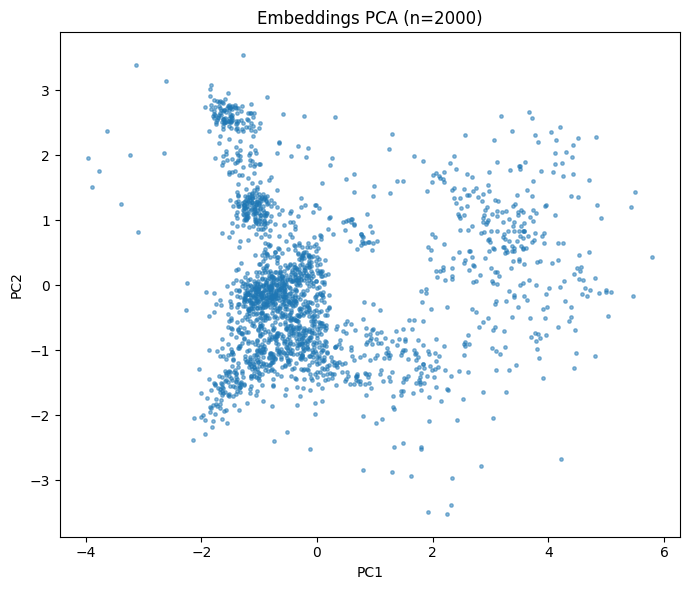

In [ ]:
import matplotlib.pyplot as plt

# PCA to 2D via truncated SVD (no sklearn required)
X = df_emb[[f"embedding_{i}" for i in range(128)]].to_numpy(dtype=np.float32)
X -= X.mean(axis=0, keepdims=True)  # centre
U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc2 = U[:, :2] * S[:2]  # project onto first two principal components

plt.figure(figsize=(7, 6))
plt.scatter(pc2[:, 0], pc2[:, 1], s=6, alpha=0.5)
plt.title(f"Presto embeddings PCA  (n={len(df_emb):,})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

con.close()

## 13) DB comparison utilities

Diagnostic cells for comparing row counts between two DuckDB embeddings cache files — useful when verifying that a freshly-built cache contains the expected samples vs. a previous reference version.

These cells are **not** part of the main pipeline and can be skipped in a fresh run.

In [8]:
import duckdb

# Adjust these paths to the two DB files you want to compare
NEW_DB_PATH = EMBEDDINGS_DB_PATH
new_db = duckdb.connect(NEW_DB_PATH, read_only=True)
new_count = new_db.execute("SELECT COUNT(*) FROM embeddings_cache").fetchone()[0]
print(f"New DB total rows : {new_count:,}")

new_db.close()


New DB total rows : 7,081,910


In [9]:
import duckdb
import pandas as pd

new_db = duckdb.connect(NEW_DB_PATH, read_only=True)

# Per-ref_id row counts from both databases
new_ref_counts = new_db.execute(
    "SELECT ref_id, COUNT(*) AS new_count FROM embeddings_cache GROUP BY ref_id ORDER BY ref_id"
).fetchdf()

new_db.close()

# Outer-join and compute difference
print(f"=== ref_id count comparison ===")
print(f"Total ref_ids in new DB  : {len(new_ref_counts):,}")


=== ref_id count comparison ===
Total ref_ids in new DB  : 340


In [11]:
MERGED_WIDE_PATH

PosixPath('/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month.parquet')

In [14]:
import pandas as pd

# Quick row-count comparison between the new and old merged wide parquets
NEW_WIDE = MERGED_WIDE_PATH  # adjust if needed
new_wide_df = pd.read_parquet(NEW_WIDE, columns=["ref_id", "sample_id"])

print(f"New merged wide rows : {len(new_wide_df):,}")
print(new_wide_df['ref_id'].nunique(), "unique ref_ids")

New merged wide rows : 7,081,910
340 unique ref_ids
340 unique ref_ids


In [16]:
# Check final anomaly columns in the new merged wide parquet  
NEW_WIDE = "/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month_with_anomalies.parquet"
new_wide_df = pd.read_parquet(NEW_WIDE, columns=['ref_id', 'sample_id'] + ANOMALY_COLS)

print(new_wide_df['ref_id'].nunique(), "unique ref_ids")
print(new_wide_df['sample_id'].nunique(), "unique sample_ids")

340 unique ref_ids
7081910 unique sample_ids
7081910 unique sample_ids


In [19]:
# select ref_id 2023_PAK_ADB-Kharif_POINT_110.geoparquet and 2023_PAK_ADB-Rabi_POINT_110.geoparquet
ref_ids_of_interest = [
    "2023_PAK_ADB-Kharif_POINT_110",
    "2023_PAK_ADB-Rabi_POINT_110"
]
subset_df = new_wide_df[new_wide_df['ref_id'].isin(ref_ids_of_interest)]
print(subset_df.head())

                                ref_id                            sample_id  \
7028643  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55265   
7028644  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55037   
7028645  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55221   
7028646  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55261   
7028647  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55034   

         CTY24_confidence_nonoutlier CTY24_anomaly_flag outlier_CTY24_cls  \
7028643                          1.0            flagged       fibre_crops   
7028644                          1.0             normal       fibre_crops   
7028645                          1.0             normal       fibre_crops   
7028646                          1.0             normal       fibre_crops   
7028647                          1.0             normal       fibre_crops   

         LC10_confidence_nonoutlier LC10_anomaly_flag outlier_

In [21]:
# find candidate in CTY24_anomaly_flag  for subset data
candidates = subset_df[subset_df['CTY24_anomaly_flag'] == "candidate"]
print(candidates)

                                ref_id                            sample_id  \
7028682  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_54997   
7028726  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_61598   
7028739  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_56596   
7028777  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55325   
7028863  2023_PAK_ADB-Kharif_POINT_110  2023_PAK_ADB-Kharif_POINT_110_55363   
...                                ...                                  ...   
7077102    2023_PAK_ADB-Rabi_POINT_110    2023_PAK_ADB-Rabi_POINT_110_29446   
7077950    2023_PAK_ADB-Rabi_POINT_110    2023_PAK_ADB-Rabi_POINT_110_35304   
7078209    2023_PAK_ADB-Rabi_POINT_110     2023_PAK_ADB-Rabi_POINT_110_4782   
7078282    2023_PAK_ADB-Rabi_POINT_110     2023_PAK_ADB-Rabi_POINT_110_4780   
7078437    2023_PAK_ADB-Rabi_POINT_110     2023_PAK_ADB-Rabi_POINT_110_3232   

         CTY24_confidence_nonoutlier CTY24_anomaly_

## One-time fix: backfill missing ref_ids into the `_with_anomalies` wide parquet

The `_with_anomalies` file has 331 ref_ids / ~6.9M rows, but the source wide file has 340 ref_ids / ~7.1M rows.  The 9 missing ref_ids were added after the initial full rerun and their anomaly scores have already been written back to the long-format geoparquets by the update-mode script.  However, the wide-parquet write-back was skipped at that time because the incremental update wasn't implemented yet.

This cell:
1. Identifies the missing `sample_id`s (present in source but not in `_with_anomalies`)
2. Reads their wide-format data from the source parquet
3. Looks up their anomaly scores from the long-format geoparquets
4. Appends those rows (with scores) to the `_with_anomalies` file via a streaming rewrite


In [15]:
import gc
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from tqdm.auto import tqdm

# -------------------------------------------------------------------
# Paths
# -------------------------------------------------------------------
SRC_WIDE = Path(
    "/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/"
    "CACHED_WIDE_MERGED/cached_wide_merged/"
    "worldcereal_all_extractions_wide_month.parquet"
)
DST_WIDE = Path(
    "/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/"
    "CACHED_WIDE_MERGED/cached_wide_merged/"
    "worldcereal_all_extractions_wide_month_with_anomalies.parquet"
)
LONG_DIR = Path(
    "/data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/"
    "MERGED_PARQUETS_PHASEII_WITH_ANOMALY"
)
ANOMALY_COLS = [
    "CTY24_confidence_nonoutlier",
    "CTY24_anomaly_flag",
    "outlier_CTY24_cls",
    "LC10_confidence_nonoutlier",
    "LC10_anomaly_flag",
    "outlier_LC10_cls",
]

# -------------------------------------------------------------------
# 1. Find missing sample_ids
# -------------------------------------------------------------------
print("Reading sample_ids from source wide parquet ...")
src_ids = pq.read_table(str(SRC_WIDE), columns=["sample_id"]).to_pandas()["sample_id"]
print(f"  Source: {len(src_ids):,} rows")

print("Reading sample_ids from existing _with_anomalies parquet ...")
dst_ids = pq.read_table(str(DST_WIDE), columns=["sample_id"]).to_pandas()["sample_id"]
print(f"  Dest:   {len(dst_ids):,} rows")

missing_ids = set(src_ids.unique()) - set(dst_ids.unique())
print(f"  Missing sample_ids: {len(missing_ids):,}")
del src_ids, dst_ids
gc.collect()

if not missing_ids:
    print("Nothing to backfill — all sample_ids are already present.")
else:
    # -------------------------------------------------------------------
    # 2. Collect anomaly scores for missing samples from long geoparquets
    # -------------------------------------------------------------------
    print("\nCollecting anomaly scores from long-format geoparquets ...")
    score_chunks = []
    for gp in tqdm(sorted(LONG_DIR.glob("*.geoparquet")), desc="Scanning", unit="file"):
        df = pd.read_parquet(gp, columns=["sample_id"] + ANOMALY_COLS)
        hits = df[df["sample_id"].isin(missing_ids)].drop_duplicates(subset="sample_id")
        if not hits.empty:
            score_chunks.append(hits)
        del df

    if score_chunks:
        scores_df = pd.concat(score_chunks, ignore_index=True).drop_duplicates(subset="sample_id")
        print(f"  Found scores for {len(scores_df):,} of {len(missing_ids):,} missing samples")
    else:
        scores_df = pd.DataFrame(columns=["sample_id"] + ANOMALY_COLS)
        print("  WARNING: No scores found in geoparquets for missing samples")

    # -------------------------------------------------------------------
    # 3. Stream the existing _with_anomalies file + append missing rows
    #    from the source wide parquet (with scores joined in)
    # -------------------------------------------------------------------
    print("\nRebuilding wide parquet with backfilled rows ...")

    # Read the existing destination schema
    dst_pf = pq.ParquetFile(str(DST_WIDE))
    dst_schema = dst_pf.schema_arrow
    print(f"  Existing schema: {len(dst_schema)} columns")

    # Prepare the source file reader for extracting missing rows
    src_pf = pq.ParquetFile(str(SRC_WIDE))

    # Ensure schema includes anomaly columns (it should, but just in case)
    extra_fields = []
    for col in ANOMALY_COLS:
        if col not in dst_schema.names:
            extra_fields.append(pa.field(col, pa.string() if "flag" in col or "cls" in col else pa.float32()))
    target_schema = pa.schema(list(dst_schema) + extra_fields) if extra_fields else dst_schema

    tmp_path = DST_WIDE.with_suffix(".backfill_tmp.parquet")
    writer = pq.ParquetWriter(
        str(tmp_path), target_schema, compression="zstd",
        use_dictionary=True, write_statistics=True,
    )

    rows_written = 0
    BATCH = 100_000

    try:
        # Phase A: Copy all existing rows from the _with_anomalies file
        print("  Phase A: copying existing rows ...")
        for batch in dst_pf.iter_batches(batch_size=BATCH):
            tbl = pa.Table.from_batches([batch])
            # Add any missing anomaly columns
            for col in ANOMALY_COLS:
                if col not in tbl.column_names:
                    tbl = tbl.append_column(col, pa.nulls(tbl.num_rows, type=pa.string() if "flag" in col or "cls" in col else pa.float32()))
            # Reorder to target schema
            tbl = tbl.select([f.name for f in target_schema])
            writer.write_table(tbl, row_group_size=BATCH)
            rows_written += tbl.num_rows
            del batch, tbl
        print(f"    → {rows_written:,} existing rows copied")

        # Phase B: Extract missing rows from source, join scores, append
        print("  Phase B: extracting and appending missing rows ...")
        rows_appended = 0
        for batch in src_pf.iter_batches(batch_size=BATCH):
            df_batch = batch.to_pandas()
            mask = df_batch["sample_id"].isin(missing_ids)
            if not mask.any():
                del df_batch, batch
                continue
            new_rows = df_batch.loc[mask].copy()
            del df_batch, batch

            # Drop any pre-existing anomaly columns from source
            cols_to_drop = [c for c in ANOMALY_COLS if c in new_rows.columns]
            if cols_to_drop:
                new_rows.drop(columns=cols_to_drop, inplace=True)

            # Join scores
            new_rows = new_rows.merge(scores_df, on="sample_id", how="left")

            # Ensure all target columns exist
            for col in ANOMALY_COLS:
                if col not in new_rows.columns:
                    new_rows[col] = float("nan")

            tbl = pa.Table.from_pandas(new_rows, schema=target_schema, safe=False)
            writer.write_table(tbl, row_group_size=BATCH)
            rows_appended += tbl.num_rows
            rows_written += tbl.num_rows
            del new_rows, tbl
            gc.collect()

        print(f"    → {rows_appended:,} missing rows appended")
        print(f"    → {rows_written:,} total rows written")

    finally:
        writer.close()

    # Atomic rename
    tmp_path.replace(DST_WIDE)
    print(f"\nDone — {DST_WIDE} now has {rows_written:,} rows")

    # Quick verification
    verify_pf = pq.ParquetFile(str(DST_WIDE))
    print(f"Verification: {verify_pf.metadata.num_rows:,} rows, "
          f"{len(verify_pf.schema_arrow)} columns")


Reading sample_ids from source wide parquet ...
  Source: 7,081,910 rows
Reading sample_ids from existing _with_anomalies parquet ...
  Source: 7,081,910 rows
Reading sample_ids from existing _with_anomalies parquet ...
  Dest:   6,936,439 rows
  Dest:   6,936,439 rows
  Missing sample_ids: 145,471
  Missing sample_ids: 145,471




Scanning:   0%|          | 0/340 [00:00<?, ?file/s]

  Found scores for 145,471 of 145,471 missing samples

Rebuilding wide parquet with backfilled rows ...
  Existing schema: 279 columns
  Phase A: copying existing rows ...
  Phase A: copying existing rows ...
    → 6,936,439 existing rows copied
  Phase B: extracting and appending missing rows ...
    → 6,936,439 existing rows copied
  Phase B: extracting and appending missing rows ...
    → 145,471 missing rows appended
    → 7,081,910 total rows written
    → 145,471 missing rows appended
    → 7,081,910 total rows written

Done — /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month_with_anomalies.parquet now has 7,081,910 rows

Done — /data/worldcereal_data/EXTRACTIONS/WORLDCEREAL/CACHED_WIDE_MERGED/cached_wide_merged/worldcereal_all_extractions_wide_month_with_anomalies.parquet now has 7,081,910 rows
Verification: 7,081,910 rows, 279 columns
Verification: 7,081,910 rows, 279 columns
